In [1]:
import torch
print("GPU 사용 가능 여부:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("연결된 GPU 이름:", torch.cuda.get_device_name(0))

GPU 사용 가능 여부: True
연결된 GPU 이름: Tesla T4


In [2]:
from google.colab import drive
import os

drive.mount('/content/drive')
!mkdir -p /content/drive/MyDrive/aiffel
os.chdir('/content/drive/MyDrive/aiffel')
os.environ["HF_HOME"] = "/content/drive/MyDrive/aiffel/hf_cache"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# 설치 (2026.09.18 기준 최신으로 고정)

%pip install -q "langgraph>=1.2,<2" "langchain>=1.4,<2" "langchain-openai>=1.6,<2" \
                "langchain-core>=1.0,<2" "langchain-community>=0.4,<1" \
                "langchain-experimental>=0.4,<1" "langchain-tavily>=0.2,<1" \
                "fpdf2>=2.8,<3" "pdfplumber>=0.11,<1"

In [4]:
# 설치된 버전 확인

from importlib.metadata import version
for p in ["langgraph", "langchain", "langchain-core", "langchain-openai",
          "langchain-community", "langchain-tavily", "fpdf2", "pdfplumber"]:
    try:
        print(f"{p:24} {version(p)}")
    except Exception as e:
        print(f"{p:24} 확인 실패 : {e}")

langgraph                1.2.11
langchain                1.4.3
langchain-core           1.6.6
langchain-openai         1.6.7
langchain-community      0.4.2
langchain-tavily         0.2.18
fpdf2                    2.8.9
pdfplumber               0.11.10


In [5]:
from langchain_core.runnables import RunnableConfig
from langchain_core.messages import AIMessage, ToolMessage
from typing import Annotated, Literal
from typing_extensions import TypedDict
from langchain_tavily import TavilySearch
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.prompts import PromptTemplate
from langchain_core.tools import tool
from langchain_community.agent_toolkits import FileManagementToolkit
from langchain_experimental.tools.python.tool import PythonAstREPLTool
from pydantic import BaseModel, Field
from fpdf import FPDF
from fpdf.enums import XPos, YPos
import random
import pdfplumber
import os
import requests
import warnings

warnings.filterwarnings("ignore")

/tmp/ipykernel_100390/4274016498.py:12: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.agent_toolkits import FileManagementToolkit
/tmp/ipykernel_100390/4274016498.py:13: DeprecationWarning: `langchain-experimental` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-experimental/issues/87 for details.
  from langchain_experimental.tools.python.tool import PythonAstREPLTool


In [6]:
# API 키 입력
import os
from getpass import getpass

# 입력창에 키를 붙여 넣으면 이 세션의 환경 변수로만 저장됩니다 (파일에는 남지 않습니다)
os.environ["OPENAI_API_KEY"] = getpass("OpenAI API 키를 붙여 넣으세요: ")
os.environ["TAVILY_API_KEY"] = getpass("Tavily API 키를 붙여 넣으세요: ")

for k in ["OPENAI_API_KEY", "TAVILY_API_KEY"]:
    print(f"{k:18}", "OK" if os.environ.get(k) else "비어 있음")

OPENAI_API_KEY     OK
TAVILY_API_KEY     OK


In [7]:
# 그래프 상태 정의

class State(TypedDict):
    query : Annotated[str, "User Question"]
    answer : Annotated[str, "LLM response"]
    messages : Annotated[list, add_messages]
    tool_call : Annotated[dict, "Tool Call Result"]

In [8]:
# LLM 정의

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o", temperature=0)

In [9]:
@tool
def read_pdf(file_path: str):
    """
    PDF 파일에서 텍스트를 추출하는 도구입니다.
    표 형식 또는 일반 텍스트가 포함된 PDF를 읽고 문자열로 반환합니다.

    file_path 예시: './report.pdf'
    """
    try:
        text = ""
        with pdfplumber.open(file_path) as pdf:
            for page in pdf.pages:
                page_text = page.extract_text()
                if page_text:
                    text += page_text + "\n"
        return text.strip() if text.strip() else "❌ PDF에서 텍스트를 추출할 수 없습니다."
    except Exception as e:
        return f"❌ PDF 읽기 오류: {str(e)}"

In [10]:
# 한글 글꼴 준비 : 없으면 내려받고, 있으면 그대로 씁니다

FONT_DIR = "./fonts"
FONT_PATH = os.path.join(FONT_DIR, "NotoSansKR.ttf")
FONT_URL = "https://github.com/google/fonts/raw/main/ofl/notosanskr/NotoSansKR%5Bwght%5D.ttf"

def ensure_korean_font():
    """한글 글꼴을 확보합니다. 성공하면 경로를, 실패하면 None을 돌려줍니다."""
    os.makedirs(FONT_DIR, exist_ok=True)

    # 이미 제대로 받아 둔 것이 있으면 그대로 씁니다 (10KB 미만이면 실패한 파일로 봅니다)
    if os.path.exists(FONT_PATH) and os.path.getsize(FONT_PATH) > 10_000:
        return FONT_PATH

    try:
        r = requests.get(FONT_URL, timeout=30)
        r.raise_for_status()
        with open(FONT_PATH, "wb") as f:
            f.write(r.content)
        print(f"글꼴을 내려받았습니다 ({os.path.getsize(FONT_PATH):,} bytes)")
        return FONT_PATH
    except Exception as e:
        print(f"[글꼴 내려받기 실패] {type(e).__name__} : {e}")
        return None

print("글꼴 경로 :", ensure_korean_font())

글꼴 경로 : ./fonts/NotoSansKR.ttf


In [11]:
@tool
def write_pdf(content: str, filename: str = "output.pdf", summary: bool = True):
    """
    텍스트를 PDF 파일로 저장하는 도구입니다.
    PDF형태의 문서로 만들어야할 때 이 도구를 사용하세요.
    """

    if summary:
        prompt = PromptTemplate.from_template("""
                당신은 보고서를 작성하는 어시스턴트입니다. 당신에겐 문서 모음이 제공되고 이를 잘 분석하여 보고서를 작성하여야 합니다.
                아래의 content는 문서 모음입니다. 문서의 제목, 본문을 잘 판단하고 정리하여 요약합니다.
                항상 구조화된 출력을 제공하세요.
                항상 마지막엔 인사이트도 첨부합니다.
                답변은 반드시 한국어로 작성하세요.

                content : {content}
                """)

        chain = prompt | llm
        content = chain.invoke({"content": content}).content

    font_path = ensure_korean_font()
    if font_path is None:
        return "❌ 한글 글꼴을 준비하지 못해 PDF를 만들 수 없습니다."

    pdf = FPDF()
    pdf.add_page()
    pdf.set_auto_page_break(auto=True, margin=15)

    try:
        pdf.add_font("NotoSans", "", font_path)
        pdf.set_font("NotoSans", size=12)
    except Exception as e:
        return f"❌ 한글 글꼴 등록 실패 : {type(e).__name__} : {e}"

    try:
        for line in content.split("\n"):
            # new_x / new_y 를 반드시 지정합니다. 아래 설명을 보십시오.
            pdf.multi_cell(0, 10, line, new_x=XPos.LMARGIN, new_y=YPos.NEXT)
        pdf.output(f"./{filename}")
    except Exception as e:
        return f"❌ PDF 작성 실패 : {type(e).__name__} : {e}"

    return f"{filename} 저장 완료"

In [12]:
# 막혔을 때 이렇게 찍어 봅니다

probe = FPDF()
probe.add_page()
fp = ensure_korean_font()
probe.add_font("NotoSans", "", fp)
probe.set_font("NotoSans", size=12)

print(f"쓰기 전     x={probe.x:.0f}  (왼쪽 여백 {probe.l_margin:.0f})")
probe.multi_cell(0, 10, "첫 줄")
print(f"기본값 뒤   x={probe.x:.0f}   <- 오른쪽 끝에 붙었습니다")

probe2 = FPDF()
probe2.add_page()
probe2.add_font("NotoSans", "", fp)
probe2.set_font("NotoSans", size=12)
probe2.multi_cell(0, 10, "첫 줄", new_x=XPos.LMARGIN, new_y=YPos.NEXT)
print(f"고친 뒤     x={probe2.x:.0f}   <- 왼쪽으로 돌아왔습니다")

쓰기 전     x=10  (왼쪽 여백 10)
기본값 뒤   x=200   <- 오른쪽 끝에 붙었습니다
고친 뒤     x=10   <- 왼쪽으로 돌아왔습니다


In [13]:
# 툴 정의
# TavilySearch       : 웹 검색 도구
# PythonAstREPLTool  : 파이썬 코드 실행 도구
# write_pdf          : pdf 생성 도구
# read_pdf           : pdf 읽기 도구
# file_delete        : 파일 삭제 도구
# list_directory     : 파일 목록 읽기 도구

tools = [
    TavilySearch(max_results=10),
    PythonAstREPLTool(),
    write_pdf,
    read_pdf,
    *FileManagementToolkit(selected_tools=["file_delete", "list_directory"]).get_tools(),
]

search_tool, code_tool, write_tool, read_tool, delete_tool, listdir_tool = tools

for t in tools:
    print(f"{t.name:18} {t.description.strip().splitlines()[0][:50]}")

tavily_search      A search engine optimized for comprehensive, accur
python_repl_ast    A Python shell. Use this to execute python command
write_pdf          텍스트를 PDF 파일로 저장하는 도구입니다.
read_pdf           PDF 파일에서 텍스트를 추출하는 도구입니다.
file_delete        Delete a file
list_directory     List files and directories in a specified folder


In [14]:
# PDF 쓰기 도구 예시

REPORT = "Langgraph_report.pdf"

print(write_tool.invoke({"content": "안녕하세요! \nLanggraph 예제코드입니다.",
                         "filename": REPORT,
                         "summary": False}))

Langgraph_report.pdf 저장 완료


In [15]:
# PDF 읽기 도구 예시

print(read_tool.invoke(REPORT))

안녕하세요!
Langgraph 예제코드입니다.


In [16]:
# 파일 목록 도구 예시

print(listdir_tool.invoke(input=""))

0904
seq2seq
RAG1
athlete_events.csv
fonts
AI_Industry_Trends_Report.pdf
모두의연구소_레포트.pdf
Langgraph_report.pdf


In [17]:
# 삭제 도구 예시

print(delete_tool.invoke(REPORT))

File deleted successfully: Langgraph_report.pdf.


In [18]:
# LLM에게 도구 할당

llm_with_tools = llm.bind_tools(tools)

In [19]:
# 전체 메시지 중 마지막 메시지를 제외하고 최대 8개까지 단기 기억(history)으로 추출

def shorterm_memory(state: State):

    if len(state["messages"]) > 9:
        history = state["messages"][-9:-1]   # 마지막(지금 질문) 앞의 8개
    elif len(state["messages"]) == 1:
        history = ""
    else:
        history = state["messages"][:-1]

    return history

In [20]:
class HistoryChecker(BaseModel):
    """
    이전의 대화 기록을 참고하여 질문에 대해 답변할 수 있는지 판단합니다.
    답변할 수 있다면 "yes", 답변할 수 없다면 "no"를 반환합니다.
    """

    yes_no : Literal["yes", "no"] = Field(..., description="""Use your previous conversation history to determine if you can answer your questions.
    Return "yes" if you can answer, "no" if you can't answer.""")

In [21]:
# LLM의 응답을 HistoryChecker 클래스 구조에 맞춰 파싱하도록 설정

history_checker = llm.with_structured_output(HistoryChecker)

In [22]:
# 히스토리 기반 답변 분기를 위한 함수 설정

def history_check(state:State):

    prompt = PromptTemplate.from_template("""

                이전의 대화 기록을 참고하여 질문에 대해 답변할 수 있는지 판단합니다.
                답변할 수 있다면 "yes", 답변할 수 없다면 "no"를 반환합니다.

                대화 기록 : {history}

                질문 : {query}

                """)

    chain = prompt | history_checker

    history = shorterm_memory(state)

    result = chain.invoke({"history":history,
                            "query":state["query"]})

    return result.yes_no

In [23]:
# 기억 기반 답변 노드

def memory_chat(state:State):

    prompt = PromptTemplate.from_template("""

                이전의 대화 기록을 참고하여 질문에 대해 답변하세요.
                아래 대화 기록을 첨부합니다.
                대화 기록을 통해 답변이 어렵다면 내부 지식을 참조하세요.
                답변은 반드시 한국어로 작성하세요.

                대화 기록 : {history}

                질문 : {query}

                """)


    chain = prompt | llm

    history = shorterm_memory(state)

    result = chain.invoke({"history":history,
                           "query":state["query"]})

    if len(state["tool_call"]) == 0:
        return {"answer":result.content,
                "messages":result,
                "tool_call":"사용된 기록 없음."}
    else:
        return {"answer":result.content,
                "messages":result}

In [24]:
# 기억 기반 답변 분기 노드

def history_node(state:State):
    if len(state["messages"]) == 1:
        return {"answer":"답변 없음",
                "tool_call":"사용된 도구 없음"}
    else:
        return state

In [25]:
# 도구 선택 노드

def select(
    state: State,
):

    prompt = PromptTemplate.from_template("""

                이전의 대화 기록을 참고하여 질문에 대해 답변하세요.
                아래 대화 기록을 첨부합니다.
                이전의 대화가 다음에 어떤 도구를 사용해야하는지 힌트가 될 수 있습니다. 꼭 참조하세요.
                도구의 변화가 큰 결과를 가져올 수 있습니다.
                들어온 메시지, 정답, 이전 기록을 모두 분석하여 가장 적절한 도구를 선택하세요.
                이미 부른 도구를 같은 인자로 다시 부르지 마십시오. 같은 결과가 돌아옵니다.
                같은 도구를 또 써야 한다면 검색어나 인자를 반드시 바꾸십시오.

                대화 기록 : {history}

                최근 사용한 도구 : {tool_name}

                정답 : {answer}

                질문 : {query}

                """)

    chain = prompt | llm_with_tools

    history = shorterm_memory(state)

    result = chain.invoke({"history" : history,
                           "tool_name" : state["tool_call"],
                            "answer": state["answer"],
                            "query": state["query"]})

    if hasattr(result, "tool_calls") and len(result.tool_calls) > 0:
        tool_calls = result.tool_calls

        return {"messages": result,
                "tool_call":tool_calls}
    else:
        return {"messages":AIMessage(content=f"""도구를 선택하지 못했습니다. 적절한 도구를 재선택하세요.
                                        """),
                                    "tool_call":"선택된 도구 없음"}

In [26]:
# 도구 실행 노드

tool_node = ToolNode(tools)

In [27]:
class AnswerChecker(BaseModel):
    """
    정답 분류기입니다.

    정답이 질문을 해결했는지 여부를 판단합니다.
    질문을 해결하지 못했을 시 해결될 때까지 도구를 이용합니다.

    질문을 해결했다면 "end", 해결하지 못했다면 "tool"을 반환합니다.
    """


    end : Literal["end", "tool"] = Field(..., description="""You are the answer sorter.

                                                                Determine if the correct answer has solved the question.
                                                                If the question is not resolved, use the tool until it is resolved.

                                                                Return "end" if you solved the question, or "tool" if you didn't.""")

In [28]:
# LLM의 응답을 AnswerChecker 클래스 구조에 맞춰 파싱하도록 설정

answer_checker = llm.with_structured_output(AnswerChecker)

In [29]:
# 답변 확인 노드

def response(state:State):
    """도구가 뱉은 결과를 사람이 읽을 답으로 바꿉니다."""

    last = state["messages"][-1]

    # tools를 지나온 경우, 마지막 메시지는 도구의 날 출력입니다.
    # 이것을 그대로 answer에 넣으면 판정기가 날 출력을 "정답"으로 보게 됩니다
    if isinstance(last, ToolMessage):

        prompt = PromptTemplate.from_template("""
                    아래 도구 실행 결과를 근거로 질문에 답하세요.
                    결과만으로 부족하면 무엇이 더 필요한지 적으세요.
                    답변은 반드시 한국어로 작성하세요.

                    도구 결과 : {tool_result}

                    질문 : {query}

                    """)

        chain = prompt | llm

        # 검색 결과는 길어질 수 있습니다. 앞부분만 넘겨 토큰을 아낍니다
        result = chain.invoke({"tool_result": str(last.content)[:4000],
                               "query": state["query"]})

        return {"answer": result.content,
                "messages": result}

    # memory_chat이나 select가 이미 사람이 읽을 답을 만들어 둔 경우
    return {"answer": getattr(last, "content", str(last))}

In [30]:
# 답변 완성 판단 분기 함수

MAX_TOOL_CALLS = 5          # 도구를 이만큼 부르고도 안 되면 사람에게 넘깁니다


def _도구서명(m):
    """어떤 도구를 어떤 인자로 불렀는지 한 덩어리로 만듭니다."""
    return tuple(sorted((tc["name"], str(sorted(tc.get("args", {}).items())))
                        for tc in m.tool_calls))


def answer_check(state:State):

    # 지금까지 부른 도구 호출을 순서대로 모읍니다
    호출들 = [_도구서명(m) for m in state["messages"]
             if isinstance(m, AIMessage) and getattr(m, "tool_calls", None)]

    # 0) 도구를 두 번이나 고르지 못했으면 더 돌아도 소용없습니다
    무선택 = sum(1 for m in state["messages"]
               if isinstance(m, AIMessage) and str(m.content).startswith("도구를 선택하지 못했습니다"))
    if 무선택 >= 2:
        print("[중단] 도구를 두 번 고르지 못했습니다. 되돌이를 멈춥니다.")
        return "end"

    # 1) 정체 : 직전과 똑같은 도구를 똑같은 인자로 또 불렀습니다.
    #    같은 입력에 같은 결과가 나오므로, 더 돌아도 달라지지 않습니다
    if len(호출들) >= 2 and 호출들[-1] == 호출들[-2]:
        print("[정체] 같은 도구를 같은 인자로 다시 불렀습니다. 되돌이를 멈춥니다.")
        return "end"

    # 2) 한계 : 충분히 시도했는데 안 됩니다. 못 한다고 말하는 것도 답입니다
    if len(호출들) >= MAX_TOOL_CALLS:
        print(f"[한계] 도구를 {MAX_TOOL_CALLS}번 불렀습니다. 여기서 멈춥니다.")
        return "end"

    # 3) 평소 판정
    prompt = PromptTemplate.from_template("""
    당신은 정답 분류기 어시스턴트입니다.

    정답이 질문을 해결하였는지 여부를 판단합니다.
    질문을 해결하지 못했다면 도구를 이용합니다.

    질문을 해결하였다면 "end", 아니라면 "tool"을 반환합니다.

    기존 History도 참고하여 답변하세요.

    History : {history}

    정답 : {answer}

    질문 : {query}
    """)

    chain = prompt | answer_checker

    history = shorterm_memory(state)

    result = chain.invoke({"history" : history,
                            "answer": state["answer"],
                            "query": state["query"]})

    return result.end

In [31]:
# 그래프 정의

graph_builder = StateGraph(State)

In [32]:
# 노드 및 엣지 정의

graph_builder.add_node("history_node", history_node)
graph_builder.add_node("memory_chat", memory_chat)
graph_builder.add_node("select", select)
graph_builder.add_node("tools", tool_node)
graph_builder.add_node("response", response)


graph_builder.add_edge(START, "history_node")
graph_builder.add_conditional_edges("history_node",
                            history_check,
                            {"yes":"memory_chat",
                             "no":"select"})
graph_builder.add_edge("select", "tools")
graph_builder.add_edge("tools", "response")
graph_builder.add_edge("memory_chat", "response")
graph_builder.add_conditional_edges("response",
                                    answer_check,
                                    {"end":END,
                                    "tool":"select"});

In [33]:
# 메모리 설정 및 그래프 컴파일

memory = InMemorySaver()

graph = graph_builder.compile(checkpointer=memory)

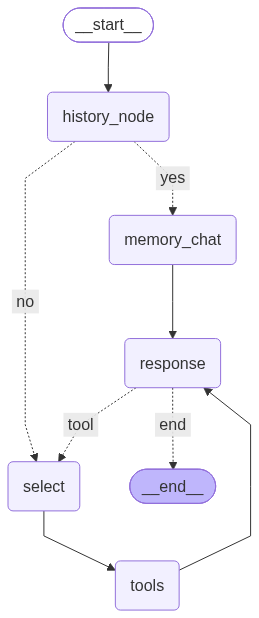

In [34]:
# 그래프 시각화
# 가끔 "ReadTimeout: HTTPSConnectionPool(host='mermaid.ink', port=443): Read timed out. (read timeout=10)"라는 에러가 발생
# 시간 초과로 그래프 생성에 실패했다는 메시지일뿐 기능과는 관계없으니 진행해도 괜찮습니다.

graph

In [35]:
# 새 config 를 만듭니다. thread_id 가 새로 정해지므로 대화 기억도 새로 시작합니다.
# 같은 대화를 이어 가려면 한 번 만든 config 를 변수에 담아 다시 쓰십시오.

def reset_config(limit=20):

    thread_id=random.randint(1,999999)

    config = RunnableConfig(recursion_limit=limit, configurable={"thread_id": thread_id})

    return config

In [36]:
# 출력 함수 정의
# mode = "values"  : 걸음마다 상태 전체를 돌려줍니다
# mode = "updates" : 그 걸음에서 바뀐 값만 돌려줍니다

def streaming(query, config, mode="values"):

    result = graph.stream({"messages":("user", query),
                         "query":query}, config=config, stream_mode=mode)

    if mode == "values":
        # values 모드는 걸음마다 "상태 전체"를 돌려줍니다.
        # 메시지를 더하지 않는 노드(history_node, response)를 지나도 한 번씩 나오므로,
        # v[-1]을 그냥 찍으면 같은 메시지가 두 번 세 번 찍힙니다.
        # 이미 찍은 개수를 기억해 두고 새로 생긴 것만 찍습니다.
        # 같은 config(thread)로 이어서 질문하면 첫 걸음의 messages 에 이전 대화까지 들어 있으므로,
        # 이번 질문부터 찍기 시작합니다
        shown = None
        for step in result:
            messages = step.get("messages", [])
            if shown is None:
                shown = max(len(messages) - 1, 0)
            for m in messages[shown:]:
                m.pretty_print()
            shown = len(messages)
    elif mode == "updates":
        for step in result:
            for k,v in step.items():
                print(f"\n\n=== {k} ===\n\n")
                print(v)

    return

In [37]:
# 측정 장치 : 걸린 시간과 바퀴 수

import time
from collections import Counter

def measured(query, config):
    """streaming과 같은 일을 하되, 바퀴 수와 걸린 시간을 함께 찍습니다."""
    t0 = time.time()
    visits = Counter()

    try:
        for step in graph.stream({"messages": ("user", query), "query": query},
                                 config=config, stream_mode="updates"):
            for node_name in step:
                visits[node_name] += 1
    except Exception as e:
        print(f"[중단] {type(e).__name__} : {str(e)[:120]}")

    elapsed = time.time() - t0
    laps = visits.get("select", 0)
    print("\n" + "-" * 50)
    print(f"걸린 시간   : {elapsed:.1f}초")
    print(f"되돌이 바퀴 : {laps}회")
    print(f"노드 방문   : {dict(visits)}")
    return elapsed, laps

In [38]:
config = reset_config()

query = "1+1은 뭔가요?"

streaming(query, config)

================================ Human Message =================================

1+1은 뭔가요?
================================== Ai Message ==================================

1+1은 2입니다.


In [39]:
config = reset_config()

query = "AI 하는 박광석에 대해 조사해주세요. 잘 정리된 보고서를 제공해주십시오. pdf 포멧의 파일로 받기를 희망합니다."

streaming(query, config)

================================ Human Message =================================

AI 하는 박광석에 대해 조사해주세요. 잘 정리된 보고서를 제공해주십시오. pdf 포멧의 파일로 받기를 희망합니다.
================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_FuXM80IZBpWkJJPwMLIFxHTq)
 Call ID: call_FuXM80IZBpWkJJPwMLIFxHTq
  Args:
    query: AI 박광석
    search_depth: advanced
================================= Tool Message =================================
Name: tavily_search

{"query": "AI 박광석", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://en.wikipedia.org/wiki/Artificial_intelligence", "title": "Artificial intelligence", "content": "Approaches\n\n   Machine learning\n   Data mining\n   Symbolic\n   Deep learning\n   Bayesian networks\n   Evolutionary algorithms\n   Neuro-symbolic AI\n   Systems integration\n   Open-source\n   Open weights\n   AI data centers\nshow\n\nApplications\n\n   Art\n       Music\n\n   Bioinformatics\n   Deepfake\n  

In [40]:
# 테스트용 query
query = "최신 AI 산업 동향에 대해 조사하고, 요약된 보고서를 PDF 파일로 생성해 주세요."
streaming(query, config)

================================ Human Message =================================

최신 AI 산업 동향에 대해 조사하고, 요약된 보고서를 PDF 파일로 생성해 주세요.
================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_S3Ed3oeFMRjbEavQIj2P451V)
 Call ID: call_S3Ed3oeFMRjbEavQIj2P451V
  Args:
    query: 최신 AI 산업 동향
    search_depth: advanced
================================= Tool Message =================================
Name: tavily_search

{"query": "최신 AI 산업 동향", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://m.fairai.or.kr/research/reports/414", "title": "인공지능 산업의 최신동향: 2025년 10월 | FAIR AI", "content": "정책·법제 - 중국 국무원, ‘AI 플러스’ 심화 추진을 위한 정책 로드맵 발표 - 대만 행정원, AI 기본법 통과 후 입법원에 제출 - 영국 과학혁신기술부, 2024년 영국 AI 산업 현황 분석 보고서 발간 - 미국 캘리포니아주 의회, 미국 최초로 미성년자 보호를 위한 AI 챗봇 규제 통과 - 중국 국가인터넷정보판공실, AI 안전 거버넌스 프레임워크 2.0 버전 발표 기업·산업 - 구글, 이미지 편집 모델 ‘제미나이 2.5 플래시 이미지’ 공개 - xAI, 에이전트 코딩 특화 AI 모델 ‘그록 코드 패스트 1’ 공개 - 청소년 자살로 피소된 오픈AI, 챗GPT 안

In [41]:
config = reset_config()

code = """
아래 코드 실행시켜주세요.

```python

result = 0

for i in range(20):
    print(f"{i+1}번째 출력: ", i+1)
    result += i

print("최종 결과: ", result)

```
"""

streaming(code, config)

================================ Human Message =================================


아래 코드 실행시켜주세요.

```python

result = 0

for i in range(20):
    print(f"{i+1}번째 출력: ", i+1)
    result += i

print("최종 결과: ", result)

```

================================== Ai Message ==================================

주어진 코드를 실행하면 다음과 같은 출력이 나옵니다:

```
1번째 출력:  1
2번째 출력:  2
3번째 출력:  3
4번째 출력:  4
5번째 출력:  5
6번째 출력:  6
7번째 출력:  7
8번째 출력:  8
9번째 출력:  9
10번째 출력:  10
11번째 출력:  11
12번째 출력:  12
13번째 출력:  13
14번째 출력:  14
15번째 출력:  15
16번째 출력:  16
17번째 출력:  17
18번째 출력:  18
19번째 출력:  19
20번째 출력:  20
최종 결과:  190
```

이 코드는 1부터 20까지의 숫자를 출력하고, `result` 변수에 0부터 19까지의 합을 더하여 최종 결과를 출력합니다. `result`의 최종 값은 0부터 19까지의 합인 190입니다.


In [42]:
config = reset_config()

streaming("""
          모두의연구소는 어떤 곳이야?
          깔끔하게 정리해서 레포트로 만들어줘.
          레포트의 형식은 pdf로 저장해주면 돼.
          이름은 "모두의연구소_레포트.pdf"로 해줘.""", config)

================================ Human Message =================================


          모두의연구소는 어떤 곳이야?
          깔끔하게 정리해서 레포트로 만들어줘.
          레포트의 형식은 pdf로 저장해주면 돼.
          이름은 "모두의연구소_레포트.pdf"로 해줘.
================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_UFaytPxlIyrHET0e2axy0E8g)
 Call ID: call_UFaytPxlIyrHET0e2axy0E8g
  Args:
    query: 모두의연구소 소개
================================= Tool Message =================================
Name: tavily_search

{"query": "모두의연구소 소개", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://namu.wiki/w/%EB%AA%A8%EB%91%90%EC%9D%98%EC%97%B0%EA%B5%AC%EC%86%8C", "title": "모두의연구소 - 나무위키", "content": "|  |  |\n --- |\n| 모두의연구소 MODULABS | |\n| modulabs | |\n| 기업명 | 모두의연구소 |\n| 설립 | 2015년 12월 5일 |\n| 국가 | 대한민국 국기 대한민국 |\n| 대표 | 김승일 |\n| 업종 | 정보서비스업 | 교육서비스업 | 전문·과학 및 기술서비스업 |\n| 기업 구분 | 중소기업 |\n| 직원 수 | 73명(2025년 5월 기준) |\n| 소재지 | 대한민국 서울특별시 강남구 강남대로 324 (역삼동,

In [43]:
# 한 번에 끝나는 질문

measured("3 곱하기 7은 얼마인가요?", reset_config())


--------------------------------------------------
걸린 시간   : 2.0초
되돌이 바퀴 : 0회
노드 방문   : {'history_node': 1, 'memory_chat': 1, 'response': 1}


(1.9880712032318115, 0)

In [45]:
# 여러 바퀴 도는 질문

measured("모두의연구소에 대해 조사해서 pdf 보고서로 만들어줘. 파일 이름은 test_report.pdf 로.", reset_config())


--------------------------------------------------
걸린 시간   : 21.2초
되돌이 바퀴 : 2회
노드 방문   : {'history_node': 1, 'select': 2, 'tools': 2, 'response': 2}


(21.22512698173523, 2)